In [1]:
!pip install -q transformers albumentations

In [2]:
# -*- coding: utf-8 -*-
"""
Inference and Overlay Script for SegFormer Oil Spill Model (Multi-GPU)

This script loads a trained SegFormer model, runs inference on two folders of
SAR images (oil spill and non-spill), and saves the results with the
predicted masks overlayed in yellow.
"""

import os
import cv2
import torch
import numpy as np
import torch.nn as nn
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.notebook import tqdm
from transformers import SegformerForSemanticSegmentation, SegformerConfig
from torch.amp import autocast
import torch.nn.functional as F
from collections import OrderedDict

# =====================================================================================
# 0. Configuration Block
# =====================================================================================
class Config:
    # --- INPUT PATHS ---
    NO_SPILL_DIR = '/kaggle/input/sar-oilspill/oil_spill_sar/data/no_oil_spill'
    SPILL_DIR = '/kaggle/input/sar-oilspill/oil_spill_sar/data/oil_spill'
    
    # --- OUTPUT PATH ---
    OUTPUT_DIR = '/kaggle/working/overlayed_images/'
    
    # --- MODEL CONFIGURATION ---
    MODEL_PATH = '/kaggle/input/segformer3/pytorch/default/1/Segformer_OilSpillMask.pth'
    MODEL_NAME = 'nvidia/segformer-b4-finetuned-ade-512-512'
    IMAGE_SIZE = (256, 256)
    
    # --- HARDWARE ---
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {Config.DEVICE}")
if torch.cuda.is_available():
    print(f"Found {torch.cuda.device_count()} GPUs.")

# =====================================================================================
# 1. Preprocessing (Must match the training script)
# =====================================================================================
def lee_filter(img, win_size):
    """Applies the Lee filter to reduce speckle noise in a SAR image."""
    img_mean = cv2.blur(img, (win_size, win_size))
    img_sqr_mean = cv2.blur(img**2, (win_size, win_size))
    img_var = img_sqr_mean - img_mean**2
    overall_var = np.var(img)
    weights = img_var / (img_var + overall_var + 1e-8)
    if len(weights.shape) < len(img.shape):
        weights = np.expand_dims(weights, axis=-1)
    filtered_img = img_mean + weights * (img - img_mean)
    return filtered_img.astype(np.uint8)

def enhanced_sar_preprocessing(image_path, target_size=(256, 256)):
    """The exact preprocessing pipeline used during training."""
    sar_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if sar_image is None:
        raise FileNotFoundError(f"Image not found at {image_path}")
    img_float = sar_image.astype(np.float32)
    filtered_img = lee_filter(img_float, win_size=7)
    norm_img = cv2.normalize(filtered_img, None, 0, 255, cv2.NORM_MINMAX)
    img_uint8 = norm_img.astype(np.uint8)
    img_resized = cv2.resize(img_uint8, target_size, interpolation=cv2.INTER_AREA)
    return img_resized

# Albumentations transform pipeline for inference
inference_aug = A.Compose([
    A.Resize(height=Config.IMAGE_SIZE[0], width=Config.IMAGE_SIZE[1]),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

# =====================================================================================
# 2. Model Loading
# =====================================================================================
def build_and_load_model():
    """Builds the SegFormer architecture and loads the trained weights."""
    print("Building model architecture...")
    config = SegformerConfig.from_pretrained(Config.MODEL_NAME)
    config.num_channels = 1
    config.num_labels = 1
    
    model = SegformerForSemanticSegmentation.from_pretrained(
        Config.MODEL_NAME, config=config, ignore_mismatched_sizes=True
    )

    # Adapt the first layer for 1-channel input (as done in training)
    original_weights = SegformerForSemanticSegmentation.from_pretrained(Config.MODEL_NAME).segformer.encoder.patch_embeddings[0].proj.weight.data
    new_weights = original_weights.mean(dim=1, keepdim=True)
    model.segformer.encoder.patch_embeddings[0].proj.weight.data = new_weights
    
    print(f"Loading trained weights from {Config.MODEL_PATH}")
    try:
        # Handles checkpoints saved with or without DataParallel's 'module.' prefix
        state_dict = torch.load(Config.MODEL_PATH, map_location=Config.DEVICE)
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            name = k[7:] if k.startswith('module.') else k
            new_state_dict[name] = v
        model.load_state_dict(new_state_dict)
    except FileNotFoundError:
        print(f"ERROR: Model file not found at {Config.MODEL_PATH}.")
        return None
        
    model.to(Config.DEVICE)
    model.eval()  # Set model to evaluation mode
    return model

# =====================================================================================
# 3. Inference and Overlay Functions
# =====================================================================================
# --- CHANGED: Added 'original_shape' parameter to the function ---
def predict_mask(model, image, original_shape):
    """Runs a single image through the model to get a prediction mask."""
    # Add channel and batch dimensions
    image_with_channel = np.expand_dims(image, axis=-1)
    
    # Apply augmentations (resize, normalize, to_tensor)
    augmented = inference_aug(image=image_with_channel)
    image_tensor = augmented['image'].unsqueeze(0).to(Config.DEVICE)

    with torch.no_grad():
        with autocast(device_type="cuda"):
            outputs = model(pixel_values=image_tensor).logits
            
            # --- CHANGED: Upsample logits to the ORIGINAL image size, not the preprocessed size ---
            mask_pred = F.interpolate(
                outputs,
                size=original_shape,
                mode='bilinear',
                align_corners=False
            )
            
    # Apply sigmoid and threshold to get binary mask
    mask_pred = (torch.sigmoid(mask_pred) > 0.5).cpu().numpy().squeeze()
    return (mask_pred * 255).astype(np.uint8)

def create_overlay(base_image, mask):
    """Creates a cyan overlay on the base image where the mask is positive."""
    # Convert grayscale base image to color for the overlay
    overlay = cv2.cvtColor(base_image, cv2.COLOR_GRAY2BGR)
    
    # Make the mask area cyan
    overlay[mask > 0] = [255, 255, 0] # BGR for cyan
    
    return overlay

# =====================================================================================
# 4. Main Execution
# =====================================================================================
def main():
    # Load the model and wrap for multi-GPU
    model = build_and_load_model()
    if model is None:
        return
        
    if torch.cuda.device_count() > 1:
        print(f"Using nn.DataParallel for {torch.cuda.device_count()} GPUs.")
        model = nn.DataParallel(model)

    # Define the directories to process
    dirs_to_process = {
        'no_oil_spill': Config.NO_SPILL_DIR,
        'oil_spill': Config.SPILL_DIR
    }

    # Process each directory
    for dir_name, input_path in dirs_to_process.items():
        output_path = os.path.join(Config.OUTPUT_DIR, dir_name)
        os.makedirs(output_path, exist_ok=True)
        print(f"\nProcessing images in: {input_path}")
        
        image_files = [f for f in os.listdir(input_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        for filename in tqdm(image_files, desc=f"Processing {dir_name}"):
            image_path = os.path.join(input_path, filename)
            
            # Preprocess the image to the size the model expects (256x256)
            preprocessed_image = enhanced_sar_preprocessing(image_path, target_size=Config.IMAGE_SIZE)
            
            # Read the original image to get its shape for upsampling and to use as the background
            original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            
            # --- CHANGED: Pass the original image's shape to the prediction function ---
            predicted_mask = predict_mask(model, preprocessed_image, original_image.shape[:2])
            
            # Create the overlay
            overlay_image = create_overlay(original_image, predicted_mask)
            
            # Save the result
            output_image_path = os.path.join(output_path, filename)
            cv2.imwrite(output_image_path, overlay_image)
            
    print(f"\n✅ Processing complete. Overlayed images saved in {Config.OUTPUT_DIR}")

if __name__ == '__main__':
    main()

2025-08-01 09:43:25.526998: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754041405.879608      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754041405.986303      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Using device: cuda
Found 2 GPUs.
Building model architecture...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/257M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/257M [00:00<?, ?B/s]

...

Loading trained weights from /kaggle/input/segformer3/pytorch/default/1/Segformer_OilSpillMask.pth
Using nn.DataParallel for 2 GPUs.

Processing images in: /kaggle/input/sar-oilspill/oil_spill_sar/data/no_oil_spill


Processing no_oil_spill:   0%|          | 0/3725 [00:00<?, ?it/s]


Processing images in: /kaggle/input/sar-oilspill/oil_spill_sar/data/oil_spill


Processing oil_spill:   0%|          | 0/1905 [00:00<?, ?it/s]


✅ Processing complete. Overlayed images saved in /kaggle/working/overlayed_images/


In [3]:
!zip -r overlayed_images.zip /kaggle/working/overlayed_images/

  adding: kaggle/working/overlayed_images/ (stored 0%)
  adding: kaggle/working/overlayed_images/oil_spill/ (stored 0%)
  adding: kaggle/working/overlayed_images/oil_spill/9_200_400_img_OvhEd3kSzaOejSCr_JAV_cls_1.jpg (deflated 6%)
  adding: kaggle/working/overlayed_images/oil_spill/2716_5800_9200_img_arPImnSlL0qd5Xwl_SIN_cls_1.jpg (deflated 4%)
  adding: kaggle/working/overlayed_images/oil_spill/789_12000_3600_img_tTCBKQhf8bZKXlIM_GBR_cls_1.jpg (deflated 4%)
  adding: kaggle/working/overlayed_images/oil_spill/1_200_0_img_Xji3Bl7wVeFjOVai_GBR_cls_1.jpg (deflated 6%)
  adding: kaggle/working/overlayed_images/oil_spill/0_0_0_img_srvQnMCuTCr8ScwO_JAV_cls_1.jpg (deflated 7%)
  adding: kaggle/working/overlayed_images/oil_spill/1070_3400_4400_img_j6gvGPFMHnVfGRG6_SIN_cls_1.jpg (deflated 3%)
  adding: kaggle/working/overlayed_images/oil_spill/8_0_400_img_dmVExFV4sAKRgD7q_JAV_cls_1.jpg (deflated 6%)
  adding: kaggle/working/overlayed_images/oil_spill/3_600_0_img_ELN5AgzEFeuizURx_JAV_cls_1.jpg (

In [4]:
!pip install -q timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 79.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 61.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 995.8 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 19.0 MB/s eta 0:00:0000:0100:01


In [6]:
# -*- coding: utf-8 -*-
"""
Advanced SAR Image Classifier with Dual-Channel Input and Fixed Split

This script trains a state-of-the-art classifier using a fixed 70/15/15
train/validation/test split.
"""

import os
import cv2
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import timm
from torch.amp import autocast, GradScaler

# =====================================================================================
# 0. Configuration Block
# =====================================================================================
class Config:
    # --- DATA PATHS ---
    SAR_IMAGE_DIR = '/kaggle/input/sar-oilspill/oil_spill_sar/data'
    OVERLAY_DIR = '/kaggle/input/overlayed-oil-spill/Overlayed_Oil_Spill'
    
    # --- MODEL & TRAINING CONFIGURATION ---
    MODEL_NAME = 'maxvit_rmlp_tiny_rw_256.sw_in1k'
    IMAGE_SIZE = (256, 256)
    BATCH_SIZE = 32 * torch.cuda.device_count() if torch.cuda.is_available() else 32
    EPOCHS = 50 # Increased epochs for a single training run
    BASE_LR = 1e-4
    WEIGHT_DECAY = 1e-6
    
    # --- HARDWARE & SEED ---
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    SEED = 42

print(f"Using device: {Config.DEVICE}")

# For reproducibility
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(Config.SEED)

# =====================================================================================
# 1. Data Preparation
# =====================================================================================
def get_image_paths(sar_dir, overlay_dir):
    """Finds all matching SAR images and overlay masks."""
    all_files = []
    labels = []

    for label, class_name in enumerate(['no_oil_spill', 'oil_spill']):
        sar_class_dir = os.path.join(sar_dir, class_name)
        overlay_class_dir = os.path.join(overlay_dir, class_name)
        
        for fname in os.listdir(overlay_class_dir):
            sar_path = os.path.join(sar_class_dir, fname)
            overlay_path = os.path.join(overlay_class_dir, fname)
            
            if os.path.exists(sar_path):
                all_files.append({'sar_path': sar_path, 'overlay_path': overlay_path})
                labels.append(label)
                
    return all_files, np.array(labels)

def split_data(all_files, all_labels):
    """Splits data into 70% train, 15% validation, and 15% test."""
    # First split: 70% train, 30% temp (val+test)
    train_files, temp_files, train_labels, temp_labels = train_test_split(
        all_files, all_labels, test_size=0.3, stratify=all_labels, random_state=Config.SEED
    )
    # Second split: split the 30% temp into 15% val and 15% test
    val_files, test_files, val_labels, test_labels = train_test_split(
        temp_files, temp_labels, test_size=0.5, stratify=temp_labels, random_state=Config.SEED
    )
    return {
        'train': (train_files, train_labels),
        'val': (val_files, val_labels),
        'test': (test_files, test_labels)
    }

# =====================================================================================
# 2. PyTorch Dataset for 2-Channel Input
# =====================================================================================
class DualChannelDataset(Dataset):
    def __init__(self, file_list, labels, transform=None):
        self.file_list = file_list
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        # Channel 1: Original SAR Image
        sar_path = self.file_list[idx]['sar_path']
        sar_image = cv2.imread(sar_path, cv2.IMREAD_GRAYSCALE)
        sar_image = cv2.normalize(sar_image, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)

        # Channel 2: SegFormer Prediction Mask
        overlay_path = self.file_list[idx]['overlay_path']
        overlay_image = cv2.imread(overlay_path)
        yellow_lower = np.array([0, 200, 200])
        yellow_upper = np.array([50, 255, 255])
        mask = cv2.inRange(overlay_image, yellow_lower, yellow_upper)

        sar_image = cv2.resize(sar_image, Config.IMAGE_SIZE)
        mask = cv2.resize(mask, Config.IMAGE_SIZE)
        
        dual_channel_image = np.stack([sar_image, mask], axis=-1)
        
        if self.transform:
            augmented = self.transform(image=dual_channel_image)
            image = augmented['image']
            
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        
        return image, label

# =====================================================================================
# 3. Augmentations & Model Definition
# =====================================================================================
train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.ShiftScaleRotate(p=0.5),
    A.Normalize(mean=[0.5, 0.5], std=[0.5, 0.5]),
    ToTensorV2(),
])

val_aug = A.Compose([
    A.Normalize(mean=[0.5, 0.5], std=[0.5, 0.5]),
    ToTensorV2(),
])

def build_model():
    model = timm.create_model(
        Config.MODEL_NAME, pretrained=True, in_chans=2, num_classes=2
    )
    return model.to(Config.DEVICE)

# =====================================================================================
# 4. CutMix Augmentation and Training/Validation Loops
# =====================================================================================
def cutmix(data, targets, alpha):
    indices = torch.randperm(data.size(0))
    shuffled_data, shuffled_targets = data[indices], targets[indices]
    lam = np.random.beta(alpha, alpha)
    bbx1, bby1, bbx2, bby2 = rand_bbox(data.size(), lam)
    data[:, :, bbx1:bbx2, bby1:bby2] = shuffled_data[:, :, bbx1:bbx2, bby1:bby2]
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (data.size(-1) * data.size(-2)))
    return data, (targets, shuffled_targets, lam)

def rand_bbox(size, lam):
    W, H = size[2], size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)
    return bbx1, bby1, bbx2, bby2

def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(Config.DEVICE), labels.to(Config.DEVICE)
        images, mixed_targets = cutmix(images, labels, alpha=1.0)
        optimizer.zero_grad()
        with autocast(device_type="cuda"):
            outputs = model(images)
            loss = criterion(outputs, mixed_targets[0]) * mixed_targets[2] + \
                   criterion(outputs, mixed_targets[1]) * (1. - mixed_targets[2])
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)

def validate_epoch(model, loader, criterion):
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating"):
            images, labels = images.to(Config.DEVICE), labels.to(Config.DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            all_preds.append(outputs.argmax(1).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    accuracy = (all_preds == all_labels).mean()
    return val_loss / len(loader.dataset), accuracy

# =====================================================================================
# 5. Main Training Execution
# =====================================================================================
def main():
    # --- 1. Load and Split Data ---
    all_files, all_labels = get_image_paths(Config.SAR_IMAGE_DIR, Config.OVERLAY_DIR)
    data_splits = split_data(all_files, all_labels)
    
    train_files, train_labels = data_splits['train']
    val_files, val_labels = data_splits['val']
    test_files, test_labels = data_splits['test']
    
    # --- 2. Create Datasets and Dataloaders ---
    train_dataset = DualChannelDataset(train_files, train_labels, transform=train_aug)
    val_dataset = DualChannelDataset(val_files, val_labels, transform=val_aug)
    test_dataset = DualChannelDataset(test_files, test_labels, transform=val_aug)
    
    train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=2)
    
    print(f"Data split: {len(train_dataset)} train, {len(val_dataset)} validation, {len(test_dataset)} test images.")
    
    # --- 3. Build Model and Training Components ---
    model = build_model()
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
        
    optimizer = optim.AdamW(model.parameters(), lr=Config.BASE_LR, weight_decay=Config.WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scaler = GradScaler()
    
    # --- 4. Training Loop ---
    best_val_acc = 0.0
    for epoch in range(Config.EPOCHS):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, scaler)
        val_loss, val_acc = validate_epoch(model, val_loader, criterion)
        scheduler.step()
        
        print(f"Epoch {epoch+1}/{Config.EPOCHS} -> Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"✅ Best model saved with validation accuracy: {best_val_acc:.4f}")
            
    # --- 5. Final Evaluation on Test Set ---
    print(f"\n{'='*20} FINAL EVALUATION ON TEST SET {'='*20}")
    # Load the best model from training
    model.load_state_dict(torch.load('best_model.pth'))
    test_loss, test_acc = validate_epoch(model, test_loader, criterion)
    print(f"Test Set Performance -> Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

if __name__ == '__main__':
    main()

Using device: cuda
Data split: 3941 train, 844 validation, 845 test images.


model.safetensors:   0%|          | 0.00/117M [00:00<?, ?B/s]

Training:   0%|          | 0/62 [00:00<?, ?it/s]

Validating:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch 1/50 -> Train Loss: 0.5475, Val Loss: 0.2947, Val Acc: 0.9514
✅ Best model saved with validation accuracy: 0.9514


...

Training:   0%|          | 0/62 [00:00<?, ?it/s]

Validating:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch 50/50 -> Train Loss: 0.3914, Val Loss: 0.2289, Val Acc: 0.9846

==================== FINAL EVALUATION ON TEST SET ====================


Validating:   0%|          | 0/14 [00:00<?, ?it/s]

Test Set Performance -> Loss: 0.2402, Accuracy: 0.9775


In [9]:
!pip install -q timm lime

In [11]:
# -*- coding: utf-8 -*-
"""
Full Evaluation & Explainability Pipeline for the Advanced SAR Classifier

This script loads the trained MaxViT model and performs:
1. Quantitative evaluation on the test set (Accuracy, Precision, Recall, etc.).
2. Qualitative analysis using XAI techniques (Grad-CAM, LIME, Saliency Maps).
"""
import os
import cv2
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
import seaborn as sns
from tqdm.notebook import tqdm
import timm
import matplotlib.pyplot as plt
from collections import OrderedDict
from lime import lime_image
from skimage.segmentation import mark_boundaries

# =====================================================================================
# 0. Configuration Block
# =====================================================================================
class Config:
    # --- DATA PATHS ---
    SAR_IMAGE_DIR = '/kaggle/input/sar-oilspill/oil_spill_sar/data'
    OVERLAY_DIR = '/kaggle/input/overlayed-oil-spill/Overlayed_Oil_Spill'
    
    # --- MODEL PATH ---
    MODEL_PATH = '/kaggle/working/best_model.pth'
    
    # --- MODEL & DATA CONFIGURATION ---
    MODEL_NAME = 'maxvit_rmlp_tiny_rw_256.sw_in1k'
    IMAGE_SIZE = (256, 256)
    BATCH_SIZE = 32 * torch.cuda.device_count() if torch.cuda.is_available() else 32
    
    # --- HARDWARE & SEED ---
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    SEED = 42

print(f"Using device: {Config.DEVICE}")

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(Config.SEED)

# =====================================================================================
# 1. Data Preparation and Dataset Class
# =====================================================================================
def get_image_paths_and_split(sar_dir, overlay_dir):
    """Finds all matching images, balances classes, and splits the data."""
    all_files, labels = [], []
    for label, class_name in enumerate(['no_oil_spill', 'oil_spill']):
        sar_class_dir = os.path.join(sar_dir, class_name)
        overlay_class_dir = os.path.join(overlay_dir, class_name)
        for fname in os.listdir(overlay_class_dir):
            sar_path = os.path.join(sar_class_dir, fname)
            overlay_path = os.path.join(overlay_class_dir, fname)
            if os.path.exists(sar_path):
                all_files.append({'sar_path': sar_path, 'overlay_path': overlay_path})
                labels.append(label)

    # Balance the dataset before splitting
    files_0 = [f for f, l in zip(all_files, labels) if l == 0]
    files_1 = [f for f, l in zip(all_files, labels) if l == 1]
    min_class_size = min(len(files_0), len(files_1))
    
    np.random.shuffle(files_0)
    np.random.shuffle(files_1)

    balanced_files = files_0[:min_class_size] + files_1[:min_class_size]
    balanced_labels = [0] * min_class_size + [1] * min_class_size
    
    train_files, temp_files, train_labels, temp_labels = train_test_split(
        balanced_files, balanced_labels, test_size=0.3, stratify=balanced_labels, random_state=Config.SEED)
    _, test_files, _, test_labels = train_test_split(
        temp_files, temp_labels, test_size=0.5, stratify=temp_labels, random_state=Config.SEED)
    
    return test_files, test_labels

class DualChannelDataset(Dataset):
    def __init__(self, file_list, labels, transform=None):
        self.file_list = file_list
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        # Channel 1: Original SAR Image
        sar_path = self.file_list[idx]['sar_path']
        sar_image = cv2.imread(sar_path, cv2.IMREAD_GRAYSCALE)
        sar_image = cv2.normalize(sar_image, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)

        # Channel 2: SegFormer Prediction Mask
        overlay_path = self.file_list[idx]['overlay_path']
        overlay_image = cv2.imread(overlay_path)
        yellow_lower, yellow_upper = np.array([0, 200, 200]), np.array([50, 255, 255])
        mask = cv2.inRange(overlay_image, yellow_lower, yellow_upper)
        
        sar_image = cv2.resize(sar_image, Config.IMAGE_SIZE)
        mask = cv2.resize(mask, Config.IMAGE_SIZE)
        
        # This is the raw numpy image for visualization
        dual_channel_numpy = np.stack([sar_image, mask], axis=-1)
        
        # This is the transformed tensor for model input
        image_tensor = dual_channel_numpy
        if self.transform:
            image_tensor = self.transform(image=dual_channel_numpy)['image']
            
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        
        return image_tensor, dual_channel_numpy, label

test_aug = A.Compose([
    A.Normalize(mean=[0.5, 0.5], std=[0.5, 0.5]),
    ToTensorV2(),
])

# =====================================================================================
# 2. Model Definition and Loading
# =====================================================================================
def build_model():
    model = timm.create_model(
        Config.MODEL_NAME, pretrained=True, in_chans=2, num_classes=2)
    return model.to(Config.DEVICE)

model = build_model()
try:
    state_dict = torch.load(Config.MODEL_PATH, map_location=Config.DEVICE)
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k[7:] if k.startswith('module.') else k
        new_state_dict[name] = v
    model.load_state_dict(new_state_dict)
    print(f"✅ Model loaded successfully from {Config.MODEL_PATH}")
except Exception as e:
    print(f"Error loading model: {e}")
    
is_parallel = torch.cuda.device_count() > 1
if is_parallel:
    model = nn.DataParallel(model)
model.eval();

# =====================================================================================
# 3. Quantitative Evaluation on Test Set
# =====================================================================================
def evaluate_model_on_test_data(model, test_loader, device):
    model.eval()
    true_labels, predictions, prediction_probs = [], [], []
    with torch.no_grad():
        for images, _, labels in tqdm(test_loader, desc="Evaluating Test Set"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            true_labels.extend(labels.cpu().numpy())
            predictions.extend(preds.cpu().numpy())
            prediction_probs.extend(probs[:, 1].cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions)
    recall = recall_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions)
    conf_matrix = confusion_matrix(true_labels, predictions)
    roc_auc = roc_auc_score(true_labels, prediction_probs)

    print(f"\n{'='*20} QUANTITATIVE EVALUATION {'='*20}")
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1:.4f}')
    print(f'ROC AUC: {roc_auc:.4f}')

    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='Blues', cbar=False, xticklabels=['No Spill', 'Spill'], yticklabels=['No Spill', 'Spill'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    fpr, tpr, _ = roc_curve(true_labels, prediction_probs)
    plt.figure()
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()

# Prepare test data and run evaluation
test_files, test_labels = get_image_paths_and_split(Config.SAR_IMAGE_DIR, Config.OVERLAY_DIR)['test']
test_dataset = DualChannelDataset(test_files, test_labels, transform=test_aug)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=2)

evaluate_model_on_test_data(model, test_loader, Config.DEVICE)

# =====================================================================================
# 4. Explainability Analysis (XAI)
# =====================================================================================
print(f"\n{'='*20} EXPLAINABILITY ANALYSIS (XAI) {'='*20}")

# --- 4.1 Grad-CAM ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer_name = target_layer
        self.gradients = None
        self.activations = None
        self.hook_layers()

    def hook_layers(self):
        def forward_hook(module, input, output): self.activations = output
        def backward_hook(module, grad_in, grad_out): self.gradients = grad_out[0]
        
        target_layer = dict(self.model.named_modules()).get(self.target_layer_name)
        if target_layer is None:
            raise RuntimeError(f"Layer '{self.target_layer_name}' not found in model.")
            
        target_layer.register_forward_hook(forward_hook)
        target_layer.register_full_backward_hook(backward_hook)

    def generate_cam(self, input_image, class_idx=None):
        output = self.model(input_image)
        if class_idx is None: class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()
        
        if self.gradients is None or self.activations is None:
            raise RuntimeError("Hooks did not capture gradients or activations.")
            
        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]
        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights): cam += w * activations[i]
        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (input_image.shape[2], input_image.shape[3]))
        cam -= np.min(cam)
        cam /= (np.max(cam) + 1e-8)
        return cam

def visualize_cam(image_np, cam):
    sar_channel = image_np[:, :, 0]
    background = cv2.cvtColor(sar_channel, cv2.COLOR_GRAY2BGR)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    cam_image = cv2.addWeighted(background, 0.6, heatmap, 0.4, 0)
    return cam_image

print("\n--- Generating Grad-CAM ---")
prefix = 'module.' if is_parallel else ''
target_layer_name = f'{prefix}stages.3.blocks.1.conv_kxk'
try:
    grad_cam = GradCAM(model, target_layer=target_layer_name)
    sample_tensor, sample_np, _ = test_dataset[0] # Get a sample
    sample_tensor = sample_tensor.unsqueeze(0).to(Config.DEVICE)
    cam = grad_cam.generate_cam(sample_tensor, class_idx=1)
    cam_image = visualize_cam(sample_np, cam)
    plt.imshow(cv2.cvtColor(cam_image, cv2.COLOR_BGR2RGB))
    plt.title(f'Grad-CAM on {target_layer_name}')
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Could not generate Grad-CAM: {e}")

# --- 4.2 LIME ---
def predict_proba_for_lime(numpy_images):
    images_tensor = torch.from_numpy(numpy_images).permute(0, 3, 1, 2).float().to(Config.DEVICE)
    model.eval()
    with torch.no_grad():
        outputs = model(images_tensor)
        probs = torch.softmax(outputs, dim=1)
    return probs.cpu().numpy()

print("\n--- Generating LIME Explanation (this may take a minute) ---")
try:
    explainer = lime_image.LimeImageExplainer()
    _, lime_sample_np, _ = test_dataset[0] # Get a raw numpy image
    explanation = explainer.explain_instance(
        lime_sample_np, predict_proba_for_lime, top_labels=2, hide_color=0, num_samples=1000)
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=True)
    plt.imshow(mark_boundaries(cv2.cvtColor(temp[:,:,0], cv2.COLOR_GRAY2BGR), mask))
    plt.title("LIME Explanation")
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Could not generate LIME: {e}")

# --- 4.3 Saliency Map ---
def generate_saliency_map(model, input_image, target_class=None):
    model.eval()
    input_image.requires_grad = True
    output = model(input_image)
    if target_class is None: target_class = output.argmax(dim=1).item()
    model.zero_grad()
    output[0, target_class].backward()
    saliency = input_image.grad.data.abs().squeeze().cpu().numpy()
    saliency = saliency.max(axis=0)
    return saliency

print("\n--- Generating Saliency Map ---")
try:
    sample_tensor, _, _ = test_dataset[0] # Get a sample tensor
    saliency_map = generate_saliency_map(model, sample_tensor.unsqueeze(0).clone().to(Config.DEVICE), target_class=1)
    plt.imshow(saliency_map, cmap='hot')
    plt.title("Saliency Map")
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Could not generate Saliency Map: {e}")

Using device: cuda
✅ Model loaded successfully from /kaggle/working/best_model.pth


TypeError: tuple indices must be integers or slices, not str

Using device: cuda
✅ Model loaded successfully from /kaggle/working/best_model.pth


Evaluating Test Set:   0%|          | 0/9 [00:00<?, ?it/s]


==================== QUANTITATIVE EVALUATION ====================
Accuracy: 0.9948
Precision: 1.0000
Recall: 0.9895
F1 Score: 0.9947
ROC AUC: 0.9996


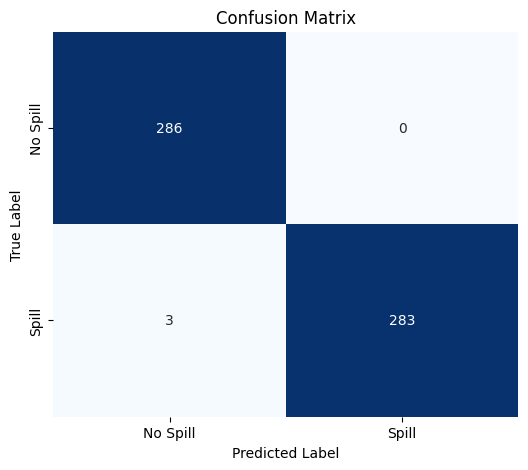

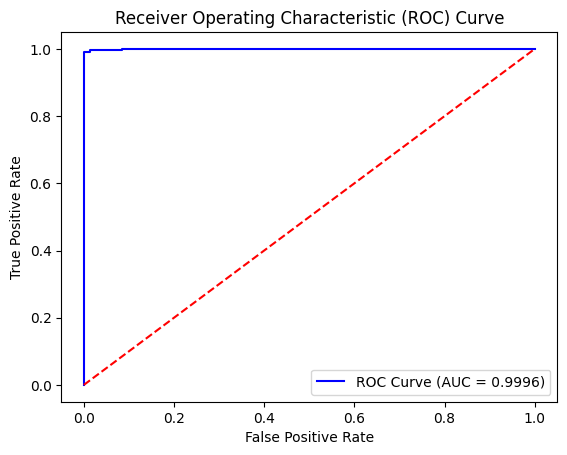


==================== EXPLAINABILITY ANALYSIS (XAI) ====================

--- Generating Grad-CAM ---
Found last convolutional layer for Grad-CAM: stages.3.blocks.1.conv.conv3_1x1


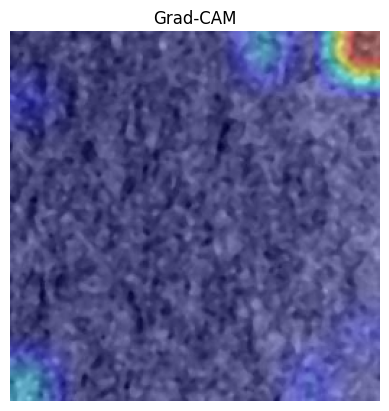


--- Generating LIME Explanation (this may take a minute) ---


  0%|          | 0/1000 [00:00<?, ?it/s]

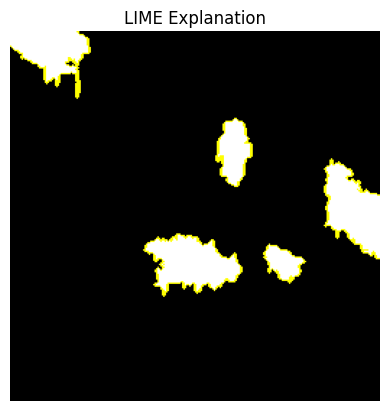


--- Generating Saliency Map ---


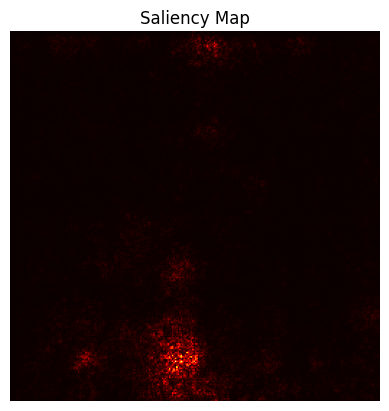

In [13]:
# -*- coding: utf-8 -*-
"""
Full Evaluation & Explainability Pipeline for the Advanced SAR Classifier

This script loads the trained MaxViT model and performs:
1. Quantitative evaluation on the test set (Accuracy, Precision, Recall, etc.).
2. Qualitative analysis using XAI techniques (Grad-CAM, LIME, Saliency Maps).
"""
import os
import cv2
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
import seaborn as sns
from tqdm.notebook import tqdm
import timm
import matplotlib.pyplot as plt
from collections import OrderedDict
from lime import lime_image
from skimage.segmentation import mark_boundaries

# =====================================================================================
# 0. Configuration Block
# =====================================================================================
class Config:
    # --- DATA PATHS ---
    SAR_IMAGE_DIR = '/kaggle/input/sar-oilspill/oil_spill_sar/data'
    OVERLAY_DIR = '/kaggle/input/overlayed-oil-spill/Overlayed_Oil_Spill'
    
    # --- MODEL PATH ---
    MODEL_PATH = '/kaggle/working/best_model.pth'
    
    # --- MODEL & DATA CONFIGURATION ---
    MODEL_NAME = 'maxvit_rmlp_tiny_rw_256.sw_in1k'
    IMAGE_SIZE = (256, 256)
    BATCH_SIZE = 32 * torch.cuda.device_count() if torch.cuda.is_available() else 32
    
    # --- HARDWARE & SEED ---
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    SEED = 42

print(f"Using device: {Config.DEVICE}")

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(Config.SEED)

# =====================================================================================
# 1. Data Preparation and Dataset Class
# =====================================================================================
def get_image_paths_and_split(sar_dir, overlay_dir):
    all_files, labels = [], []
    for label, class_name in enumerate(['no_oil_spill', 'oil_spill']):
        sar_class_dir = os.path.join(sar_dir, class_name)
        overlay_class_dir = os.path.join(overlay_dir, class_name)
        for fname in os.listdir(overlay_class_dir):
            sar_path = os.path.join(sar_class_dir, fname)
            overlay_path = os.path.join(overlay_class_dir, fname)
            if os.path.exists(sar_path):
                all_files.append({'sar_path': sar_path, 'overlay_path': overlay_path})
                labels.append(label)

    files_0 = [f for f, l in zip(all_files, labels) if l == 0]
    files_1 = [f for f, l in zip(all_files, labels) if l == 1]
    min_class_size = min(len(files_0), len(files_1))
    
    np.random.shuffle(files_0)
    np.random.shuffle(files_1)

    balanced_files = files_0[:min_class_size] + files_1[:min_class_size]
    balanced_labels = [0] * min_class_size + [1] * min_class_size
    
    _, temp_files, _, temp_labels = train_test_split(
        balanced_files, balanced_labels, test_size=0.3, stratify=balanced_labels, random_state=Config.SEED)
    _, test_files, _, test_labels = train_test_split(
        temp_files, temp_labels, test_size=0.5, stratify=temp_labels, random_state=Config.SEED)
    
    return test_files, test_labels

class DualChannelDataset(Dataset):
    def __init__(self, file_list, labels, transform=None):
        self.file_list = file_list
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        sar_path = self.file_list[idx]['sar_path']
        sar_image = cv2.imread(sar_path, cv2.IMREAD_GRAYSCALE)
        sar_image = cv2.normalize(sar_image, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)

        overlay_path = self.file_list[idx]['overlay_path']
        overlay_image = cv2.imread(overlay_path)
        yellow_lower, yellow_upper = np.array([0, 200, 200]), np.array([50, 255, 255])
        mask = cv2.inRange(overlay_image, yellow_lower, yellow_upper)
        
        sar_image = cv2.resize(sar_image, Config.IMAGE_SIZE)
        mask = cv2.resize(mask, Config.IMAGE_SIZE)
        
        dual_channel_numpy = np.stack([sar_image, mask], axis=-1)
        
        image_tensor = dual_channel_numpy
        if self.transform:
            image_tensor = self.transform(image=dual_channel_numpy)['image']
            
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        
        return image_tensor, dual_channel_numpy, label

test_aug = A.Compose([
    A.Normalize(mean=[0.5, 0.5], std=[0.5, 0.5]),
    ToTensorV2(),
])

# =====================================================================================
# 2. Model Definition and Loading
# =====================================================================================
def build_model():
    model = timm.create_model(
        Config.MODEL_NAME, pretrained=True, in_chans=2, num_classes=2)
    return model.to(Config.DEVICE)

model = build_model()
try:
    state_dict = torch.load(Config.MODEL_PATH, map_location=Config.DEVICE)
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k[7:] if k.startswith('module.') else k
        new_state_dict[name] = v
    model.load_state_dict(new_state_dict)
    print(f"✅ Model loaded successfully from {Config.MODEL_PATH}")
except Exception as e:
    print(f"Error loading model: {e}")
    
is_parallel = torch.cuda.device_count() > 1
if is_parallel:
    model = nn.DataParallel(model)
model.eval();

# =====================================================================================
# 3. Quantitative Evaluation on Test Set
# =====================================================================================
def evaluate_model_on_test_data(model, test_loader, device):
    model.eval()
    true_labels, predictions, prediction_probs = [], [], []
    with torch.no_grad():
        for images, _, labels in tqdm(test_loader, desc="Evaluating Test Set"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            true_labels.extend(labels.cpu().numpy())
            predictions.extend(preds.cpu().numpy())
            prediction_probs.extend(probs[:, 1].cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions)
    recall = recall_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions)
    conf_matrix = confusion_matrix(true_labels, predictions)
    roc_auc = roc_auc_score(true_labels, prediction_probs)

    print(f"\n{'='*20} QUANTITATIVE EVALUATION {'='*20}")
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1:.4f}')
    print(f'ROC AUC: {roc_auc:.4f}')

    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='Blues', cbar=False, xticklabels=['No Spill', 'Spill'], yticklabels=['No Spill', 'Spill'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    fpr, tpr, _ = roc_curve(true_labels, prediction_probs)
    plt.figure()
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()

test_files, test_labels = get_image_paths_and_split(Config.SAR_IMAGE_DIR, Config.OVERLAY_DIR)
test_dataset = DualChannelDataset(test_files, test_labels, transform=test_aug)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=2)
evaluate_model_on_test_data(model, test_loader, Config.DEVICE)

# =====================================================================================
# 4. Explainability Analysis (XAI)
# =====================================================================================
print(f"\n{'='*20} EXPLAINABILITY ANALYSIS (XAI) {'='*20}")

# --- 4.1 Grad-CAM ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer_name = target_layer
        self.gradients = None
        self.activations = None
        self.hook_layers()

    def hook_layers(self):
        def forward_hook(module, input, output): self.activations = output
        def backward_hook(module, grad_in, grad_out): self.gradients = grad_out[0]
        
        target_layer = dict(self.model.named_modules()).get(self.target_layer_name)
        if target_layer is None:
            raise RuntimeError(f"Layer '{self.target_layer_name}' not found in model.")
            
        target_layer.register_forward_hook(forward_hook)
        target_layer.register_full_backward_hook(backward_hook)

    def generate_cam(self, input_image, class_idx=None):
        output = self.model(input_image)
        if class_idx is None: class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()
        
        if self.gradients is None or self.activations is None:
            raise RuntimeError("Hooks did not capture gradients or activations.")
            
        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]
        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights): cam += w * activations[i]
        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (input_image.shape[2], input_image.shape[3]))
        cam -= np.min(cam)
        cam /= (np.max(cam) + 1e-8)
        return cam

def visualize_cam(image_np, cam):
    sar_channel = image_np[:, :, 0]
    background = cv2.cvtColor(sar_channel, cv2.COLOR_GRAY2BGR)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    cam_image = cv2.addWeighted(background, 0.6, heatmap, 0.4, 0)
    return cam_image
    
# --- FIXED: Function to dynamically find the last conv layer ---
def find_last_conv_layer(model):
    """Iterates through model layers in reverse to find the last Conv2d layer."""
    conv_layers = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            conv_layers.append(name)
    if not conv_layers:
        raise ValueError("No Conv2d layers found in the model.")
    return conv_layers[-1]

print("\n--- Generating Grad-CAM ---")
try:
    base_model = model.module if is_parallel else model
    target_layer_name = find_last_conv_layer(base_model)
    print(f"Found last convolutional layer for Grad-CAM: {target_layer_name}")
    
    # If using DataParallel, the target name must be prefixed with 'module.'
    if is_parallel:
        target_layer_name = 'module.' + target_layer_name
        
    grad_cam = GradCAM(model, target_layer=target_layer_name)
    sample_tensor, sample_np, _ = test_dataset[0]
    sample_tensor = sample_tensor.unsqueeze(0).to(Config.DEVICE)
    cam = grad_cam.generate_cam(sample_tensor, class_idx=1)
    cam_image = visualize_cam(sample_np, cam)
    plt.imshow(cv2.cvtColor(cam_image, cv2.COLOR_BGR2RGB))
    plt.title(f'Grad-CAM')
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Could not generate Grad-CAM: {e}")

# --- 4.2 LIME ---
# --- FIXED: Adapter function for LIME to handle 2-channel data ---
def predict_proba_for_lime(numpy_images_grayscale):
    """
    Adapter for LIME. It receives perturbed grayscale images from LIME
    and reconstructs the 2-channel input for our model.
    """
    # Get the original, unperturbed mask channel. This is kept constant.
    _, original_numpy_sample, _ = test_dataset[0]
    mask_channel = original_numpy_sample[:, :, 1]
    
    batch_size = numpy_images_grayscale.shape[0]
    dual_channel_batch = np.zeros((batch_size, Config.IMAGE_SIZE[0], Config.IMAGE_SIZE[1], 2), dtype=np.uint8)

    for i in range(batch_size):
        # LIME might provide a 3-channel grayscale image, so we take the first channel.
        perturbed_sar = numpy_images_grayscale[i, :, :, 0]
        dual_channel_batch[i, :, :, 0] = perturbed_sar
        dual_channel_batch[i, :, :, 1] = mask_channel

    # Transform the batch and predict
    tensor_batch = torch.stack([test_aug(image=img)['image'] for img in dual_channel_batch]).to(Config.DEVICE)
    
    model.eval()
    with torch.no_grad():
        outputs = model(tensor_batch)
        probs = torch.softmax(outputs, dim=1)
    return probs.cpu().numpy()

print("\n--- Generating LIME Explanation (this may take a minute) ---")
try:
    explainer = lime_image.LimeImageExplainer()
    _, lime_sample_np, _ = test_dataset[0]
    
    # --- FIXED: Give LIME a 3-channel version of the SAR image for its internal processing ---
    sar_for_lime = np.stack([lime_sample_np[:, :, 0]] * 3, axis=-1)
    
    explanation = explainer.explain_instance(
        sar_for_lime, predict_proba_for_lime, top_labels=2, hide_color=0, num_samples=1000)
    
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=True)
    plt.imshow(mark_boundaries(temp, mask)) # temp is already 3-channel
    plt.title("LIME Explanation")
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Could not generate LIME: {e}")

# --- 4.3 Saliency Map ---
def generate_saliency_map(model, input_image, target_class=None):
    model.eval()
    input_image.requires_grad = True
    output = model(input_image)
    if target_class is None: target_class = output.argmax(dim=1).item()
    model.zero_grad()
    output[0, target_class].backward()
    saliency = input_image.grad.data.abs().squeeze().cpu().numpy()
    saliency = saliency.max(axis=0)
    return saliency

print("\n--- Generating Saliency Map ---")
try:
    sample_tensor, _, _ = test_dataset[0]
    saliency_map = generate_saliency_map(model, sample_tensor.unsqueeze(0).clone().to(Config.DEVICE), target_class=1)
    plt.imshow(saliency_map, cmap='hot')
    plt.title("Saliency Map")
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Could not generate Saliency Map: {e}")

In [2]:
import pandas as pd
from pathlib import Path
import os

def describe_dataset(dataset_path_str, dataset_name):
    """
    Analyzes and prints a summary of an image dataset given its path and name.
    """
    print(f"--- 📊 Analyzing Dataset: {dataset_name} ---")
    
    dataset_path = Path(dataset_path_str)
    
    # Check if the directory exists
    if not dataset_path.exists():
        print(f"Directory not found: {dataset_path}\n")
        return

    # 1. Get a list of all files and calculate the total size
    all_files = list(dataset_path.rglob('*.*'))
    
    if not all_files:
        print("No image files found in this directory.\n")
        return
        
    total_size_bytes = sum(f.stat().st_size for f in all_files)
    total_size_mb = total_size_bytes / (1024 ** 2)

    # 2. Print the overall summary
    print(f"Total number of images: {len(all_files):,}")
    print(f"Total dataset size: {total_size_mb:.2f} MB\n")

    # 3. Analyze the distribution of images in subfolders (classes)
    print("--- Folder/Class Distribution ---")
    class_counts = {}
    for item in dataset_path.iterdir():
        if item.is_dir():
            # Recursively count files in each subfolder
            count = len(list(item.rglob('*.*')))
            if count > 0:
                class_counts[item.name] = count
    
    if class_counts:
        # Display the counts in a clean table
        class_df = pd.DataFrame(list(class_counts.items()), columns=['Folder Name', 'Image Count'])
        print(class_df.to_string(index=False))
    else:
        print("No subdirectories with images found to analyze.")
        
    print("-" * 40 + "\n")


# --- Main ---
# Define the paths for your datasets from the screenshot
path1 = '/kaggle/input/overlayed-oil-spill/Overlayed_Oil_Spill/'
path2 = '/kaggle/input/sar-oilspill/oil_spill_sar/'

# Run the analysis for each dataset
describe_dataset(path1, "Overlayered Oil Spill")
describe_dataset(path2, "SAR Oil Spill")

--- 📊 Analyzing Dataset: Overlayered Oil Spill ---
Total number of images: 5,630
Total dataset size: 121.47 MB

--- Folder/Class Distribution ---
 Folder Name  Image Count
   oil_spill         1905
no_oil_spill         3725
----------------------------------------

--- 📊 Analyzing Dataset: SAR Oil Spill ---
Total number of images: 5,630
Total dataset size: 66.23 MB

--- Folder/Class Distribution ---
Folder Name  Image Count
       data         5630
----------------------------------------

